# Tutorial: Mapping with World Bank Official Boundaries in Python


This notebook shows how to:


1. Select a country and admin level.
2. Download administrative boundaries from Space2Stats.
3. Load World Bank official boundary layers.
4. Overlay official and disputed lines with clear cartographic symbology.


The workflow is designed for reproducibility and publication-ready outputs.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/worldbank/WB_GAD/blob/main/notebooks/TUTORIAL_drawing_WB_maps.ipynb)

In [1]:
# If needed, uncomment and run the next line in a fresh environment:
# !pip install -q geopandas matplotlib space2stats-client mapclassify

import warnings
warnings.filterwarnings("ignore")

import sys, os
import urllib.parse
import requests
import mapclassify

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd 
import geopandas as gpd

from matplotlib import colors
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely import bounds, box
from io import BytesIO
from urllib.parse import quote
from space2stats_client import Space2StatsClient

In [2]:
# Examples: "KEN", "NPL", "ETH", "LBN", "UKR"
ISO3 = "KEN"
ADM_LEVEL = "ADM2"  # choose from "ADM0", "ADM1", "ADM2"
# Optional: if your environment has SSL issues, try verify_ssl=False
client = Space2StatsClient(verify_ssl=False)

print(f"Selected country: {ISO3}, admin level: {ADM_LEVEL}")

Selected country: KEN, admin level: ADM2


## 2) Download administrative boundaries from Space2Stats


`fetch_admin_boundaries` returns a GeoDataFrame for the selected country and level.

In [5]:
adm_gdf = client.fetch_admin_boundaries(ISO3, ADM_LEVEL)
adm_gdf = adm_gdf.to_crs(4326)

''' # You can explore S2S
topics = client.get_topics()
pd.options.display.max_colwidth = 15
topics

properties = client.get_properties("urbanization_ghssmod")
list(properties['name'])
'''

# Fetch some data from S2S on total population and exposure to flood
df = client.get_aggregate(
    aggregation_type="sum",          # Type of aggregation to perform on the data
    gdf=adm_gdf,                     # Area of Interest
    spatial_join_method="centroid",  # Spatial join method (between h3 cells and each feature)
    fields=['ghs_22_count','ghs_23_count','ghs_30_count','ghs_total_count','ghs_22_pop','ghs_23_pop','ghs_30_pop','ghs_total_pop'],                      # Fields from Space2Stats to query    
)

# Calculate % urban by population
df['percent_urban_pop'] = (df['ghs_30_pop'] + df['ghs_23_pop'] + df['ghs_22_pop']) / df['ghs_total_pop'] * 100
# Calculate % urban by count
df['percent_urban_count'] = (df['ghs_30_count'] + df['ghs_23_count'] + df['ghs_22_count']) / df['ghs_total_count'] * 100

df.head()

Failed to get summary for 37
Failed to get summary for 39
Failed to get summary for 41
Failed to get summary for 81
Failed to get summary for 108
Failed to get summary for 171
Failed to get summary for 232
Failed to get summary for 251


,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry,ghs_22_count,ghs_23_count,ghs_30_count,ghs_total_count,ghs_22_pop,ghs_23_pop,ghs_30_pop,ghs_total_pop,percent_urban_pop,percent_urban_count
0,Ainabkoi,,3690345B95414198105650,KEN,ADM2,"POLYGON ((35.4633 0.5072, 35.46246 0.50691, 35...",82.0,0.0,9.0,591.0,35758.007014,0.000000,36932.997773,178649.304942,40.689218,15.397631
1,Ainamoi,,3690345B54801368411234,KEN,ADM2,"POLYGON ((35.32495 -0.25056, 35.3225 -0.24841,...",0.0,15.0,0.0,240.0,0.000000,55777.152543,0.000000,188129.955143,29.648204,6.250000
2,Aldai,,3690345B36924206491537,KEN,ADM2,"POLYGON ((35.13034 0.1363, 35.12748 0.13635, 3...",0.0,3.0,0.0,479.0,0.000000,5499.816279,0.000000,210151.478652,2.617072,0.626305
3,Alego Usonga,,3690345B57306569752992,KEN,ADM2,"POLYGON ((34.21848 0.16479, 34.21677 0.1634, 3...",0.0,8.0,0.0,590.0,0.000000,20940.586736,0.000000,202994.651706,10.315832,1.355932
4,Awendo,,3690345B13715496647196,KEN,ADM2,"POLYGON ((34.62157 -0.9854, 34.61932 -0.9833, ...",0.0,2.0,0.0,240.0,0.000000,9543.388448,0.000000,112938.361220,8.450086,0.833333


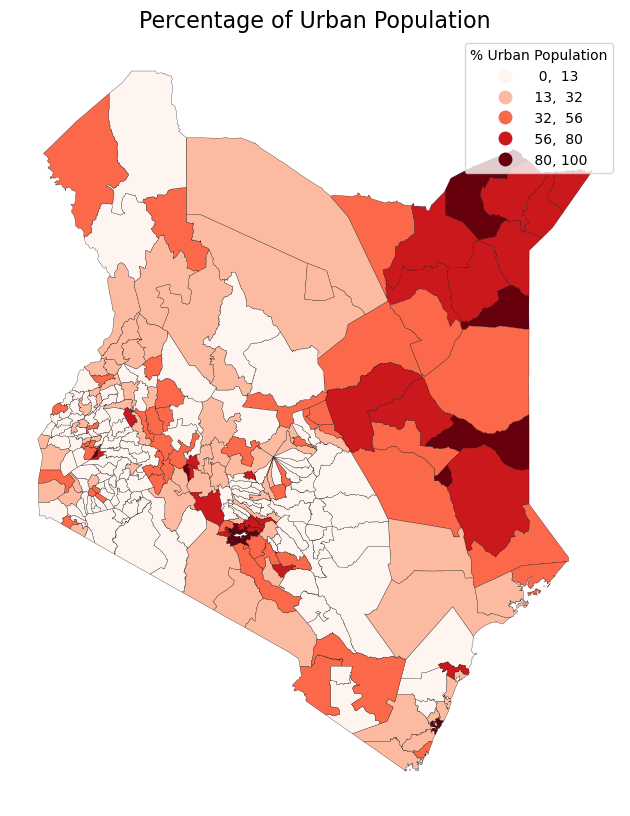

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
df.plot(
    ax=ax, column="percent_urban_pop", legend=True, 
    cmap="Reds", scheme="natural_breaks", 
    k=5, legend_kwds=dict(title='% Urban Population', fmt="{:,.0f}"),
    linewidth=0.2, edgecolor='black')
plt.title("Percentage of Urban Population", fontsize=16)
plt.axis("off")
plt.show()

## 3) Load World Bank Official Boundaries and NDLSA layer


This section reads official layers from the World Bank Data Catalog (DDH).
The NDLSA layer includes non-disputed and disputed land/sea areas used for official cartographic representation.

In [7]:
# We can also read these from the ESRI rest endpoint through the World Bank's GeoWB
in_url = 'https://services.arcgis.com/iQ1dY19aHwbSDYIF/ArcGIS/rest/services/World_Bank_Global_Administrative_Divisions/FeatureServer/{layer_num}/query?where="FID">0&outFields=*&f=pgeojson'

# SSL errors are common when working inside the World Bank firewall. If you encounter these, you can bypass them with the code below
response = requests.get(urllib.parse.quote(in_url.format(layer_num=1), safe=':/?=&'), verify=False) # <--- Ignore SSL
country_polygons = gpd.read_file(BytesIO(response.content))

response = requests.get(urllib.parse.quote(in_url.format(layer_num=0), safe=':/?=&'), verify=False) # <--- Ignore SSL
country_lines = gpd.read_file(BytesIO(response.content))

response = requests.get(urllib.parse.quote(in_url.format(layer_num=5), safe=':/?=&'), verify=False) # <--- Ignore SSL
ndlsa_polygons = gpd.read_file(BytesIO(response.content))

In [8]:
country_polygons.head()

,FID,ISO_A3,ISO_A2,WB_A3,HASC_0,GAUL_0,WB_REGION,WB_STATUS,SOVEREIGN,NAM_0,GlobalID,Shape__Area,Shape__Length,geometry
0,1,CHN,CN,CHN,CN,147295,EAP,Member State,CHN,China,18e80244-e6e8-47db-b162-f897783cfc94,951.457299,526.750372,"MULTIPOLYGON (((117.58675 38.59517, 117.58909 ..."
1,2,JPN,JP,JPN,JP,126,Other,Member State,JPN,Japan,02059b27-00bd-4709-b58c-7a34b643b501,38.693407,242.013236,"MULTIPOLYGON (((137.48411 34.67386, 137.46683 ..."
2,3,KOR,KR,KOR,KR,202,EAP,Member State,KOR,Republic of Korea,6e9581e5-a6fc-4b9f-9dbb-63e50d52f29e,10.094104,90.730206,"MULTIPOLYGON (((126.05363 36.19852, 126.05372 ..."
3,4,PRK,KP,PRK,KP,67,Other,Non Member State,PRK,D. P. R. of Korea,76ca781e-4bcd-4796-a845-a0df67a09163,12.944317,53.421387,"MULTIPOLYGON (((126.95508 38.16282, 126.95184 ..."
4,5,RUS,RU,RUS,RU,204,ECA,Member State,RUS,Russian Federation,b5d1953a-35f1-4066-8880-9def04f37afe,2916.695517,3105.140948,"MULTIPOLYGON (((130.61904 48.88019, 130.60659 ..."


In [9]:
country_lines.head()

,FID,Style,GlobalID,Shape__Length,geometry
0,1,Dashed,31a2853b-4f08-4949-8371-4f20b5db670a,4.440112,"LINESTRING (78.93677 33.38697, 78.92813 33.389..."
1,2,Dashed,995ea3cb-2e11-4868-a066-bb63e99d132f,7.938323,"LINESTRING (77.95537 35.48312, 77.95559 35.489..."
2,3,Dashed,50c05972-a2e8-485d-80bc-8bcd2a55e993,0.091238,"LINESTRING (78.73976 32.69549, 78.73769 32.694..."
3,4,Dashed,f89bb72b-e42c-4763-8fac-ff47cca36269,0.125411,"LINESTRING (78.66413 32.65731, 78.67022 32.662..."
4,5,Dashed,0424032e-237b-44c1-a601-aab768c499d9,0.110658,"LINESTRING (78.63173 32.63466, 78.63513 32.630..."


In [10]:
ndlsa_polygons.head()

,FID,ISO_A3,ISO_A2,WB_A3,HASC_0,GAUL_0,WB_REGION,WB_STATUS,SOVEREIGN,NAM_0,GlobalID,Shape__Area,Shape__Length,geometry
0,1,,,,,0,,Non-determined legal status area,,Aksai Chin,8c78850f-aac6-4d1f-8b7a-3afb052a5bb3,3.089963,12.378435,"POLYGON ((80.32496 35.47225, 80.32024 35.47073..."
1,2,,,,,0,,Non-determined legal status area,,Chumar East,6876eb83-0e1f-4ab1-8485-15fba4605210,0.001533,0.216649,"POLYGON ((78.73976 32.69549, 78.73769 32.69454..."
2,3,,,,,0,,Non-determined legal status area,,Chumar West,db46f3b5-c61b-4830-9e6c-c3365cc1b762,0.002020,0.202925,"POLYGON ((78.63173 32.63466, 78.63513 32.63014..."
3,4,,,,,0,,Non-determined legal status area,,Demchok,a2d9c450-5efa-45ca-9ada-6bb52ecfaa50,0.143413,2.577544,"POLYGON ((79.276 32.55567, 79.27549 32.55678, ..."
4,5,,,,,0,,Non-determined legal status area,,Jadh Ganga Valley,ff65eeb5-3fe9-4f4c-be19-4a70d16fe605,0.138363,2.045179,"POLYGON ((79.41238 31.07234, 79.40839 31.07028..."


# Improve the contextual boundaries of the map

A choropleth map floating in a white pane is not good practice; these countries are (mostly) not islands. This section will add gray country polygons and thin country lines to the map, which will make it easier to understand the location of the highlighted country and its neighbors.

Additionally, this will look at the specific way the World Bank deals with Non-determined Legal Status Areas (NDLSA) in their cartography, and how to use the NDLSA layer to add the appropriate shading to these areas on the map.

In [11]:
# isolate the adm0 layer to ignore the current country
adm0 = country_polygons[country_polygons['ISO_A3'] != ISO3]
adm0_color = "dimgrey"

# Simple version

Just the neighbouring countries and the official admin boundaries

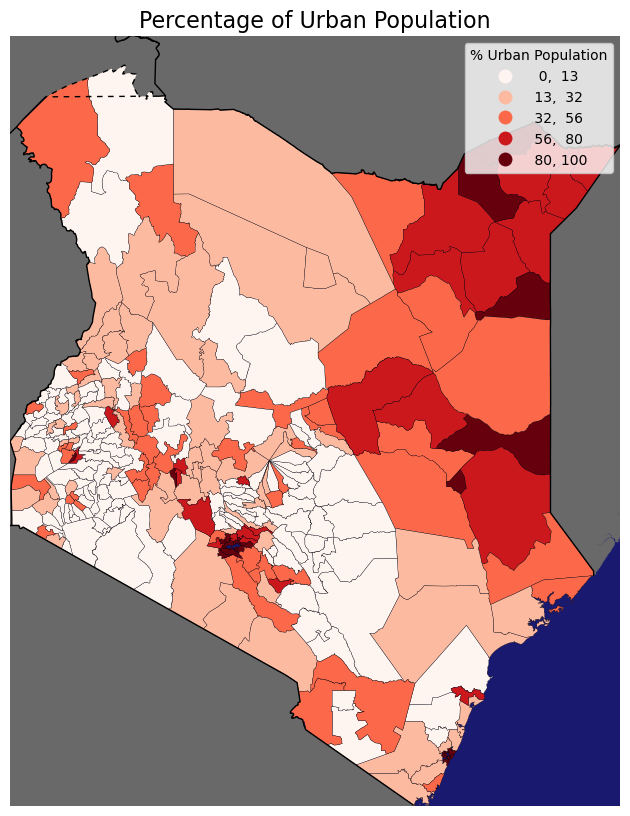

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
df.plot(
    ax=ax, column="percent_urban_pop", legend=True, 
    cmap="Reds", scheme="natural_breaks", 
    k=5, legend_kwds=dict(title='% Urban Population', fmt="{:,.0f}"),
    linewidth=0.2, edgecolor='black'
)
#plot the neighbouring countries
adm0.plot(ax=ax, legend=False, facecolor=adm0_color, edgecolor=adm0_color, linewidth=0.1)
# Plot the adm0 lines
for label, mdata in country_lines.groupby("Style"):
    if label == "Solid":
        mdata.plot(ax=ax, color="black", linewidth=1)
    elif label == "Dashed":
        mdata.plot(ax=ax, color="black", linewidth=1, linestyle=(3, (4, 4)))
    elif label == "Dotted":
        mdata.plot(ax=ax, color="black", linewidth=1, linestyle=(1, (1, 4)))
    elif label == "Tightly Dashed":
        mdata.plot(ax=ax, color="black", linewidth=1, linestyle=(3, (3, 3)))

# Set extent to S2S data
ax.set_xlim(df.total_bounds[0], df.total_bounds[2])
ax.set_ylim(df.total_bounds[1], df.total_bounds[3])

# Plot the ocean
ocean = gpd.GeoDataFrame(geometry=[box(*df.total_bounds)], crs=df.crs)
ocean.plot(ax=ax, color="midnightblue", zorder=0)
plt.title("Percentage of Urban Population", fontsize=16)
plt.axis("off")
plt.show()

# NDLSA areas are complicated

You can see in the map above of Kenya (hopefully) that we have a NDLSA in the NW corner, bordering South Sudan. The rule for NDLSAs indicates they should be shaded a colour that is half way between the coloured administrative areas and the grey background of the map. This is a bit tricky to do, but we can use the NDLSA layer to identify the areas that need to be shaded, and then use a custom color map to shade them appropriately.

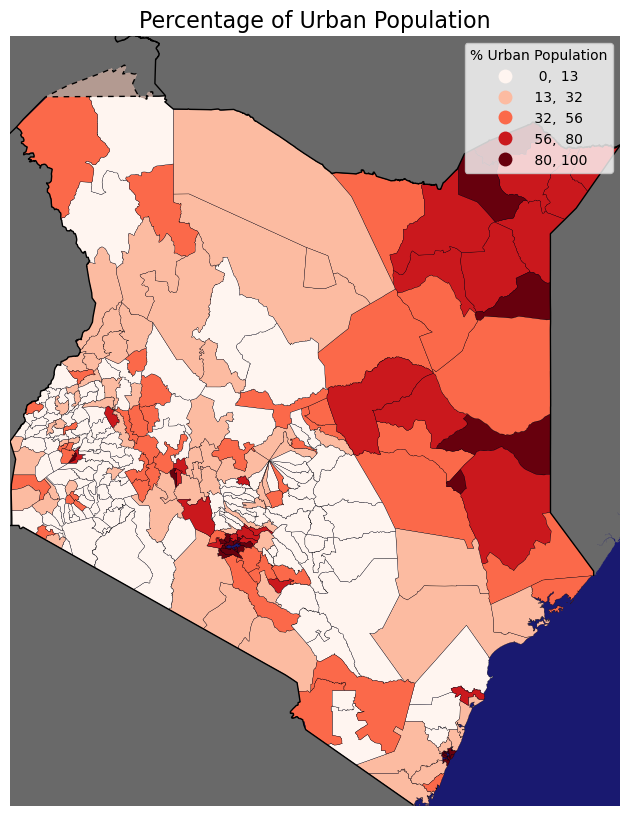

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
df.plot(
    ax=ax, column="percent_urban_pop", legend=True, 
    cmap="Reds", scheme="natural_breaks", 
    k=5, legend_kwds=dict(title='% Urban Population', fmt="{:,.0f}"),
    linewidth=0.2, edgecolor='black'
)

# Get the colours for each feature in the GeoDataFrame based on the classified data
# Create a new data frame that stores the RGB values for each feature in the 
map_df = df.copy()
# Remove entries where percent_urban_pop is NaN to avoid errors in classification
map_df = map_df[~map_df['percent_urban_pop'].isna()]
data_classified = mapclassify.NaturalBreaks(map_df['percent_urban_pop'], k=5)
cmap = plt.cm.Reds
norm = mcolors.BoundaryNorm(data_classified.bins, cmap.N)
sel_colors = [cmap(norm(value)) for value in map_df['percent_urban_pop']]

map_df['r_val'] = [color[0] for color in sel_colors]
map_df['g_val'] = [color[1] for color in sel_colors]
map_df['b_val'] = [color[2] for color in sel_colors]
map_df['a_val'] = [color[3] for color in sel_colors]


#plot the neighbouring countries
adm0.plot(ax=ax, legend=False, facecolor=adm0_color, edgecolor=adm0_color, linewidth=0.1)

# NDLSAs that intersect with the source data need to be halfway between adm0 and the fill colour
adm0_rgba = mcolors.to_rgba(adm0_color)
# First, identify the NDLSA polygons that intersect with the current country
sel_ndlsa = ndlsa_polygons[ndlsa_polygons.intersects(df.unary_union)]
sel_ndlsa["r_val"] = adm0_rgba[0]
sel_ndlsa["g_val"] = adm0_rgba[1]
sel_ndlsa["b_val"] = adm0_rgba[2]
sel_ndlsa["a_val"] = adm0_rgba[3]

# Next, identify the features from the source data that intersect with the NDLSA polygons
for idx, row in sel_ndlsa.iterrows():
    intersecting_features = map_df[map_df.intersects(row.geometry)]
    for col in ['r_val', 'g_val', 'b_val', 'a_val']:
        sel_ndlsa.at[idx, col] = (sel_ndlsa.at[idx, col] + intersecting_features[col].mean()) / 2

# Plot the NDLSA polygons with the new RGBA values
sel_ndlsa['color'] = sel_ndlsa.apply(lambda row: (row['r_val'], row['g_val'], row['b_val'], row['a_val']), axis=1)
sel_ndlsa.plot(ax=ax, legend=False, facecolor=sel_ndlsa['color'], edgecolor=sel_ndlsa['color'], linewidth=0.5)
# Plot the adm0 lines
for label, mdata in country_lines.groupby("Style"):
    if label == "Solid":
        mdata.plot(ax=ax, color="black", linewidth=1)
    elif label == "Dashed":
        mdata.plot(ax=ax, color="black", linewidth=1, linestyle=(3, (4, 4)))
    elif label == "Dotted":
        mdata.plot(ax=ax, color="black", linewidth=1, linestyle=(1, (1, 4)))
    elif label == "Tightly Dashed":
        mdata.plot(ax=ax, color="black", linewidth=1, linestyle=(3, (3, 3)))


# Set extent to S2S data
ax.set_xlim(df.total_bounds[0], df.total_bounds[2])
ax.set_ylim(df.total_bounds[1], df.total_bounds[3])
# Plot the ocean
ocean = gpd.GeoDataFrame(geometry=[box(*df.total_bounds)], crs=df.crs)
ocean.plot(ax=ax, color="midnightblue", zorder=0)
plt.title("Percentage of Urban Population", fontsize=16)
plt.axis("off")

plt.show()